# Yöntem 2: RNN/LSTM ile Topic Classification

Bu notebook'ta AG NEWS veri seti üzerinde RNN/LSTM modelleri kullanarak topic classification yapıyoruz.

## Yaklaşım:
- **Girdi**: Önceden eğitilmiş GloVe kelime vektörleri
- **Model**: LSTM/GRU tabanlı RNN mimarisi
- **Vektör Boyutları**: 100
- **Optimizasyon**: Random Search ile hiperparametre optimizasyonu
- **Strateji**: Transfer learning (freeze → fine-tuning)

## 1. Kütüphaneler ve Ayarlar

In [1]:
# Temel kütüphaneler
import pandas as pd
import numpy as np
import os
import pickle
import zipfile
import urllib.request
import warnings
warnings.filterwarnings('ignore')

# NLP kütüphaneleri
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# Deep Learning kütüphaneleri
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Random Search için
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# NLTK verilerini indir
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

print("Kütüphaneler yüklendi!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

Kütüphaneler yüklendi!
TensorFlow version: 2.19.0
GPU available: []


## 2. Veri Yükleme ve Ön İşleme

In [2]:
# Eğitim verisini başlıksız oku ve sütunları ata
train_df = pd.read_csv("archive/train.csv", header=None)
train_df.columns = ["label", "title", "description"]

# Gereksiz başlık satırlarını ve sayısal olmayan label'ları temizle
train_df = train_df[train_df["label"] != "Class Index"]
train_df = train_df[train_df["label"] != "label"]
train_df = train_df[pd.to_numeric(train_df["label"], errors='coerce').notna()]
train_df["label"] = train_df["label"].astype(int)

# Metinleri birleştir (title + description)
train_df["combined_text"] = train_df["title"].fillna("") + " " + train_df["description"].fillna("")

# Metin temizleme fonksiyonu
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Metinleri temizle
train_df["cleaned_text"] = train_df["combined_text"].apply(clean_text)

# Boş metinleri filtrele
train_df = train_df[train_df["cleaned_text"].str.len() > 0]

sample_size = 10000
train_subset = train_df.groupby('label', group_keys=False).apply(lambda x: x.sample(min(len(x), sample_size), random_state=42)).reset_index(drop=True)

# Test verisini de aynı şekilde yükle ve işle
test_df = pd.read_csv("archive/test.csv", header=None)
test_df.columns = ["label", "title", "description"]
test_df = test_df[test_df["label"] != "Class Index"]
test_df = test_df[test_df["label"] != "label"]
test_df = test_df[pd.to_numeric(test_df["label"], errors='coerce').notna()]
test_df["label"] = test_df["label"].astype(int)
test_df["combined_text"] = test_df["title"].fillna("") + " " + test_df["description"].fillna("")
test_df["cleaned_text"] = test_df["combined_text"].apply(clean_text)
test_df = test_df[test_df["cleaned_text"].str.len() > 0]

print(f"Her sınıftan {sample_size} örnekle oluşturulan eğitim seti: {train_subset.shape}")
print(f"Temizlenmiş test seti: {test_df.shape}")

Her sınıftan 10000 örnekle oluşturulan eğitim seti: (140000, 5)
Temizlenmiş test seti: (70000, 5)


## 3. GloVe Embeddings Yükleme

In [3]:
import requests
import zipfile
import io

def download_glove_embeddings(glove_dir="../glove", dim=100):
    """GloVe dosyasını indirir ve çıkarır (eğer yoksa)"""
    # Mutlak path oluştur
    glove_dir = os.path.abspath(glove_dir)
    glove_path = os.path.join(glove_dir, f"glove.6B.{dim}d.txt")
    
    # Dosya zaten varsa, direkt path'i döndür
    if os.path.exists(glove_path):
        print(f"GloVe vektörleri zaten mevcut: {glove_path}")
        return glove_path
    
    # Klasör yoksa oluştur
    os.makedirs(glove_dir, exist_ok=True)
    
    print(f"GloVe vektörleri indiriliyor (boyut: {dim}d)...")
    print("Not: Bu büyük bir dosya (~850MB), indirme işlemi birkaç dakika sürebilir.")
    
    try:
        url = "https://nlp.stanford.edu/data/glove.6B.zip"
        print("İndirme başlıyor...")
        
        # Stream ile indirme (büyük dosyalar için)
        response = requests.get(url, stream=True, timeout=300)  # 5 dakika timeout
        response.raise_for_status()  # HTTP hatalarını yakalar
        
        total_size = int(response.headers.get('content-length', 0))
        
        # Progress bar ile indirme
        with tqdm(total=total_size, unit='B', unit_scale=True, desc="İndiriliyor") as pbar:
            content = io.BytesIO()
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    content.write(chunk)
                    pbar.update(len(chunk))
        
        print("İndirme tamamlandı, zip dosyasından çıkarılıyor...")
        
        # Zip dosyasını çıkar
        with zipfile.ZipFile(content, 'r') as zip_ref:
            # Tüm dosyaları listele
            file_list = zip_ref.namelist()
            print(f"Zip içindeki dosyalar: {file_list}")
            
            # Sadece istenen boyuttaki dosyayı çıkar (disk alanı tasarrufu için)
            target_file = f"glove.6B.{dim}d.txt"
            if target_file in file_list:
                print(f"{target_file} çıkarılıyor...")
                zip_ref.extract(target_file, glove_dir)
                print(f"GloVe vektörleri başarıyla indirildi ve çıkarıldı: {glove_path}")
            else:
                print(f"Hata: {target_file} zip dosyasında bulunamadı!")
                print(f"Mevcut dosyalar: {file_list}")
                raise FileNotFoundError(f"{target_file} dosyası bulunamadı")
        
        # İndirilen dosyanın varlığını kontrol et
        if not os.path.exists(glove_path):
            raise FileNotFoundError(f"Dosya çıkarıldıktan sonra bulunamadı: {glove_path}")
            
        return glove_path
        
    except requests.exceptions.RequestException as e:
        print(f"İndirme hatası: {e}")
        print("İnternet bağlantınızı kontrol edin veya daha sonra tekrar deneyin.")
        raise
    except zipfile.BadZipFile as e:
        print(f"Zip dosyası bozuk: {e}")
        raise
    except Exception as e:
        print(f"Beklenmeyen hata: {e}")
        print("GloVe vektörlerini manuel olarak indirmeniz gerekebilir.")
        print("İndirme linki: https://nlp.stanford.edu/data/glove.6B.zip")
        print(f"Dosyayı {glove_dir} klasörüne çıkarın.")
        raise

def load_glove_embeddings(glove_file, max_vocab_size=50000):
    """GloVe embeddings'i dictionary olarak yükle"""
    if not os.path.exists(glove_file):
        raise FileNotFoundError(f"GloVe dosyası bulunamadı: {glove_file}")
    
    embeddings_dict = {}
    print(f"GloVe embeddings yükleniyor: {glove_file}")
    
    # Önce toplam satır sayısını hesapla
    print("Dosya boyutu hesaplanıyor...")
    try:
        with open(glove_file, 'r', encoding='utf-8') as f:
            total_lines = sum(1 for _ in f)
    except UnicodeDecodeError:
        print("UTF-8 okuma hatası, latin-1 encoding deneniyor...")
        with open(glove_file, 'r', encoding='latin-1') as f:
            total_lines = sum(1 for _ in f)
    
    print(f"Toplam {total_lines} satır bulundu")
    
    # Embeddings'i yükle
    loaded_count = 0
    embedding_dim = None
    
    try:
        with open(glove_file, 'r', encoding='utf-8') as f:
            for i, line in enumerate(tqdm(f, desc="GloVe Yükleniyor", total=min(total_lines, max_vocab_size))):
                if loaded_count >= max_vocab_size:
                    print(f"Maksimum vocabulary boyutu ({max_vocab_size}) sınırına ulaşıldı")
                    break
                
                line = line.strip()
                if not line:  # Boş satırları atla
                    continue
                    
                try:
                    values = line.split()
                    if len(values) < 2:  # En az word + 1 dimension olmalı
                        continue
                        
                    word = values[0]
                    vector = np.asarray(values[1:], dtype='float32')
                    
                    # İlk vektörden embedding boyutunu belirle
                    if embedding_dim is None:
                        embedding_dim = len(vector)
                        print(f"Embedding boyutu tespit edildi: {embedding_dim}")
                    
                    # Boyut kontrolü
                    if len(vector) != embedding_dim:
                        print(f"Uyarı: {word} kelimesi için boyut uyumsuzluğu ({len(vector)} != {embedding_dim})")
                        continue
                    
                    embeddings_dict[word] = vector
                    loaded_count += 1
                    
                except (ValueError, IndexError) as e:
                    print(f"Uyarı: Satır {i+1} işlenirken hata: {e}")
                    continue
                    
    except UnicodeDecodeError:
        print("UTF-8 okuma hatası, latin-1 encoding ile tekrar deneniyor...")
        with open(glove_file, 'r', encoding='latin-1') as f:
            # Aynı işlemi latin-1 ile tekrarla
            for i, line in enumerate(tqdm(f, desc="GloVe Yükleniyor", total=min(total_lines, max_vocab_size))):
                if loaded_count >= max_vocab_size:
                    break
                    
                line = line.strip()
                if not line:
                    continue
                    
                try:
                    values = line.split()
                    if len(values) < 2:
                        continue
                        
                    word = values[0]
                    vector = np.asarray(values[1:], dtype='float32')
                    
                    if embedding_dim is None:
                        embedding_dim = len(vector)
                        print(f"Embedding boyutu tespit edildi: {embedding_dim}")
                    
                    if len(vector) != embedding_dim:
                        continue
                    
                    embeddings_dict[word] = vector
                    loaded_count += 1
                    
                except (ValueError, IndexError):
                    continue
    
    if not embeddings_dict:
        raise ValueError("Hiçbir embedding yüklenemedi! Dosya formatını kontrol edin.")
    
    print(f"Başarıyla yüklenen kelime sayısı: {len(embeddings_dict)}")
    print(f"Embedding boyutu: {embedding_dim}")
    
    return embeddings_dict, embedding_dim

def get_glove_embeddings(glove_dir="../glove", dim=100, max_vocab_size=50000):
    # Önce dosyayı indir/kontrol et
    glove_path = download_glove_embeddings(glove_dir, dim)
    
    # Sonra yükle
    embeddings_dict, embedding_dim = load_glove_embeddings(glove_path, max_vocab_size)
    
    return embeddings_dict, embedding_dim

try:
        # GloVe embeddings'i al
        embeddings, dim = get_glove_embeddings(
            glove_dir="../glove", 
            dim=100, 
            max_vocab_size=50000
        )
        
        # Test
        test_words = ["hello", "world", "python", "machine", "learning"]
        print(f"\nTest kelimeleri:")
        for word in test_words:
            if word in embeddings:
                print(f"✓ '{word}': {embeddings[word][:5]}... (boyut: {len(embeddings[word])})")
            else:
                print(f"✗ '{word}': Bulunamadı")
                
except Exception as e:
        print(f"Hata oluştu: {e}")

GloVe vektörleri zaten mevcut: c:\Users\alper\OneDrive\Masaüstü\dersler\yap470\topic_calssifier\glove\glove.6B.100d.txt
GloVe embeddings yükleniyor: c:\Users\alper\OneDrive\Masaüstü\dersler\yap470\topic_calssifier\glove\glove.6B.100d.txt
Dosya boyutu hesaplanıyor...
Toplam 400000 satır bulundu


GloVe Yükleniyor:   0%|          | 0/50000 [00:00<?, ?it/s]

Embedding boyutu tespit edildi: 100
Maksimum vocabulary boyutu (50000) sınırına ulaşıldı
Başarıyla yüklenen kelime sayısı: 50000
Embedding boyutu: 100

Test kelimeleri:
✓ 'hello': [ 0.26688  0.39632  0.6169  -0.77451 -0.1039 ]... (boyut: 100)
✓ 'world': [ 0.49177  1.1164   1.1424   0.14381 -0.10696]... (boyut: 100)
✓ 'python': [ 0.24934    0.68318   -0.044711  -1.3842    -0.0073079]... (boyut: 100)
✓ 'machine': [-0.65365  0.49419 -0.26245 -0.20722 -0.11413]... (boyut: 100)
✓ 'learning': [ 0.64812  0.69878 -0.39947  0.77634 -0.13132]... (boyut: 100)


## 4. Metin Tokenization ve Sequence Preparation

In [4]:
# Tokenizer oluştur
MAX_VOCAB_SIZE = 50000
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')

# Tüm metinler üzerinde fit et
all_texts = list(train_subset['cleaned_text']) + list(test_df['cleaned_text'])
tokenizer.fit_on_texts(all_texts)

# Metinleri sequence'lere çevir
train_sequences = tokenizer.texts_to_sequences(train_subset['cleaned_text'])
test_sequences = tokenizer.texts_to_sequences(test_df['cleaned_text'])

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Training sequences: {len(train_sequences)}")
print(f"Test sequences: {len(test_sequences)}")

# Sequence uzunluklarını analiz et
train_lengths = [len(seq) for seq in train_sequences]
test_lengths = [len(seq) for seq in test_sequences]

print(f"\nSequence length statistics:")
print(f"Train - Mean: {np.mean(train_lengths):.1f}, Median: {np.median(train_lengths):.1f}, Max: {np.max(train_lengths)}")
print(f"Test - Mean: {np.mean(test_lengths):.1f}, Median: {np.median(test_lengths):.1f}, Max: {np.max(test_lengths)}")

# Maksimum sequence uzunluğunu belirle (95. percentile)
MAX_SEQUENCE_LENGTH = int(np.percentile(train_lengths + test_lengths, 95))
print(f"\nSelected MAX_SEQUENCE_LENGTH: {MAX_SEQUENCE_LENGTH}")

# Padding uygula
X_train = pad_sequences(train_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test = pad_sequences(test_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# Labels
y_train = train_subset['label'].values 
y_test = test_df['label'].values 

# One-hot encoding
num_classes = len(np.unique(y_train))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(f"\nFinal data shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train_cat.shape}")
print(f"y_test: {y_test_cat.shape}")
print(f"Number of classes: {num_classes}")

Vocabulary size: 414330
Training sequences: 140000
Test sequences: 70000

Sequence length statistics:
Train - Mean: 48.6, Median: 48.0, Max: 1473
Test - Mean: 48.6, Median: 48.0, Max: 507

Selected MAX_SEQUENCE_LENGTH: 83

Final data shapes:
X_train: (140000, 83)
X_test: (70000, 83)
y_train: (140000, 14)
y_test: (70000, 14)
Number of classes: 14


## 5. Embedding Matrix Oluşturma

In [5]:
def create_embedding_matrix(tokenizer, embeddings_dict, embedding_dim):
    """Tokenizer vocabulary için embedding matrix oluştur"""
    
    vocab_size = len(tokenizer.word_index) + 1  # +1 for padding token
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    
    found_words = 0
    missing_words = []
    
    print("Embedding matrix oluşturuluyor...")
    
    for word, index in tqdm(tokenizer.word_index.items()):
        if word in embeddings_dict:
            embedding_matrix[index] = embeddings_dict[word]
            found_words += 1
        else:
            missing_words.append((word, index))
    
    print(f"Bulunan kelimeler: {found_words}/{len(tokenizer.word_index)}")
    print(f"Eksik kelimeler: {len(missing_words)}")
    

    
    return embedding_matrix

embeddings_dict = embeddings
embedding_dim = dim

# Embedding matrix oluştur
embedding_matrix = create_embedding_matrix(tokenizer, embeddings_dict, embedding_dim)
print(f"\nEmbedding matrix shape: {embedding_matrix.shape}")

Embedding matrix oluşturuluyor...


  0%|          | 0/414330 [00:00<?, ?it/s]

Bulunan kelimeler: 41956/414330
Eksik kelimeler: 372374

Embedding matrix shape: (414331, 100)


## 6. Model Mimarisi Tanımlama

In [6]:
def create_rnn_model(vocab_size, embedding_dim, embedding_matrix, max_sequence_length, 
                     num_classes, rnn_type='LSTM', num_layers=1, hidden_units=128, 
                     dropout_rate=0.3, learning_rate=0.001, trainable_embedding=False):
    """RNN modeli oluştur"""
    
    model = Sequential()
    
    # Embedding layer (GloVe ile başlatılmış)
    embedding_layer = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_sequence_length,
        trainable=trainable_embedding  # Transfer learning için başlangıçta False
    )
    model.add(embedding_layer)
    
    # RNN layers
    for i in range(num_layers):
        return_sequences = (i < num_layers - 1)  # Son katman hariç sequence döndür
        
        if rnn_type == 'LSTM':
            model.add(LSTM(hidden_units, return_sequences=return_sequences, dropout=dropout_rate))
        elif rnn_type == 'GRU':
            model.add(GRU(hidden_units, return_sequences=return_sequences, dropout=dropout_rate))
        elif rnn_type == 'BiLSTM':
            model.add(Bidirectional(LSTM(hidden_units//2, return_sequences=return_sequences, dropout=dropout_rate)))
        elif rnn_type == 'BiGRU':
            model.add(Bidirectional(GRU(hidden_units//2, return_sequences=return_sequences, dropout=dropout_rate)))
    
    # Dense layers
    model.add(Dense(hidden_units//2, activation='relu'))
    model.add(Dropout(dropout_rate))
    
    # Output layer
    model.add(Dense(num_classes, activation='softmax'))
    
    # Compile
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

## 7. Training/Validation Split

In [7]:
# Training ve validation split
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train_cat, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Training split: {X_train_split.shape}")
print(f"Validation split: {X_val_split.shape}")
print(f"Test set: {X_test.shape}")

Training split: (112000, 83)
Validation split: (28000, 83)
Test set: (70000, 83)


## 8. Hiperparametre Optimizasyonu için Random Search

In [8]:
# Genel importer
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
import time
from datetime import datetime, timedelta

# 3 farklı RNN modeli için ayrı hiperparametre arama uzayları
rnn_models_config = {
    'BiLSTM': {
        'rnn_type': ['BiLSTM'],
        'num_layers': [1, 2, 3],  # BiLSTM ile güvenli tüm layer sayıları
        'hidden_units': [64, 128, 256, 512],
        'dropout_rate': [0.2, 0.3, 0.4, 0.5],
        'learning_rate': [0.001, 0.003, 0.005, 0.01],
        'batch_size': [32, 64, 128]
    },
    'GRU': {
        'rnn_type': ['GRU'],
        'num_layers': [1, 2],  # GRU için daha güvenli layer sayıları
        'hidden_units': [64, 128, 256],  # GRU hızlı olduğu için biraz daha az
        'dropout_rate': [0.2, 0.3, 0.4],
        'learning_rate': [0.001, 0.005, 0.01],
        'batch_size': [32, 64, 128]
    },
    'LSTM': {
        'rnn_type': ['LSTM'],
        'num_layers': [1, 2],  # LSTM için güvenli layer sayıları
        'hidden_units': [64, 128, 256],
        'dropout_rate': [0.3, 0.4, 0.5],  # LSTM için biraz daha yüksek dropout
        'learning_rate': [0.001, 0.003, 0.005],
        'batch_size': [32, 64]  # LSTM daha yavaş olduğu için küçük batch
    }
}

# Sabit embedding boyutu
EMBEDDING_DIM = 100

# Her model için deneme sayısı kontrolü
number_of_trials_per_model = 4  # Her RNN modeli için kaç deneme yapılacak

def random_search_single_rnn(rnn_type, param_space, n_trials, sample_size=10000):
    """Tek bir RNN modeli için random search"""
    
    print(f"\n{'='*60}")
    print(f"{rnn_type} MODEL HIPERPARAMETRE ARAŞTIRMASI")
    print(f"{'='*60}")
    
    # Küçük sample ile hızlı test için
    sample_indices = np.random.choice(len(X_train_split), min(sample_size, len(X_train_split)), replace=False)
    X_sample = X_train_split[sample_indices]
    y_sample = y_train_split[sample_indices]
    
    # Validation sample
    val_sample_indices = np.random.choice(len(X_val_split), min(1000, len(X_val_split)), replace=False)
    X_val_sample = X_val_split[val_sample_indices]
    y_val_sample = y_val_split[val_sample_indices]
    
    best_params = None
    best_score = 0
    results = []
    successful_trials = 0
    trial_times = []
    
    print(f"Parametreler: {n_trials} trial, {len(X_sample)} sample")
    print(f"Embedding: {EMBEDDING_DIM}D GloVe (sabit)")
    
    # Model başlangıç zamanı
    model_start_time = time.time()
    
    # GloVe embeddings'i yükle (eğer daha önce yüklenmediyse)
    if 'embedding_matrix' not in globals():
        glove_file = f'../glove/glove.6B.{EMBEDDING_DIM}d.txt'
        if not os.path.exists(glove_file):
            print(f"GloVe {EMBEDDING_DIM}D indiriliyor...")
            glove_file = download_glove_embeddings(EMBEDDING_DIM)
        
        print("GloVe embeddings yükleniyor...")
        embeddings_dict, vocab_size = load_glove_embeddings(glove_file, max_vocab_size=30000)
        
        print("Embedding matrix oluşturuluyor...")
        global embedding_matrix
        embedding_matrix = create_embedding_matrix(
            tokenizer, 
            embeddings_dict, 
            EMBEDDING_DIM, 
        )
    
    for trial in range(n_trials):
        # Trial başlangıç zamanı
        trial_start_time = time.time()
        
        # Ortalama süre hesapla ve tahmini süre göster
        if trial_times:
            avg_trial_time = np.mean(trial_times)
            remaining_trials = n_trials - trial
            estimated_remaining_time = avg_trial_time * remaining_trials
            
            # Zaman formatı
            remaining_minutes = int(estimated_remaining_time // 60)
            remaining_seconds = int(estimated_remaining_time % 60)
            
            print(f"\n--- {rnn_type} Trial {trial + 1}/{n_trials} ---")
            print(f"Ortalama trial süresi: {avg_trial_time:.1f}s")
            print(f"Tahmini kalan süre: {remaining_minutes}m {remaining_seconds}s")
        else:
            print(f"\n--- {rnn_type} Trial {trial + 1}/{n_trials} ---")
            print(f"İlk trial - süre tahmini hesaplanıyor...")
        
        # Bu RNN için rastgele parametreler seç
        params = {}
        for key, values in param_space.items():
            params[key] = np.random.choice(values)
        
        # Embedding boyutunu ekle
        params['embedding_dim'] = EMBEDDING_DIM
        
        print(f"Parameters: {params}")
        
        try:
            # Model oluştur
            model = create_rnn_model(
                vocab_size=len(tokenizer.word_index) + 1,
                embedding_dim=EMBEDDING_DIM,
                embedding_matrix=embedding_matrix,
                max_sequence_length=MAX_SEQUENCE_LENGTH,
                num_classes=num_classes,
                rnn_type=params['rnn_type'],
                num_layers=int(params['num_layers']),
                hidden_units=int(params['hidden_units']),
                dropout_rate=float(params['dropout_rate']),
                learning_rate=float(params['learning_rate'])
            )
            
            # Callbacks
            early_stopping = EarlyStopping(
                monitor='val_accuracy', 
                patience=2, 
                restore_best_weights=True,
                verbose=0
            )
            
            # Kısa eğitim
            history = model.fit(
                X_sample, y_sample,
                validation_data=(X_val_sample, y_val_sample),
                epochs=3,  # Hızlı test için
                batch_size=int(params['batch_size']),
                callbacks=[early_stopping],
                verbose=0
            )
            
            # En iyi validation accuracy
            val_accuracy = max(history.history['val_accuracy'])
            successful_trials += 1
            
            # Trial bitiş zamanı ve süre hesaplama
            trial_end_time = time.time()
            trial_duration = trial_end_time - trial_start_time
            trial_times.append(trial_duration)
            
            print(f"Validation accuracy: {val_accuracy:.4f}")
            print(f"Trial süresi: {trial_duration:.1f}s")
            print(f"Trial başarılı! (Toplam: {successful_trials})")
            
            # Sonuçları kaydet
            result = params.copy()
            result['val_accuracy'] = val_accuracy
            result['trial_duration'] = trial_duration
            results.append(result)
            
            # En iyi parametreleri güncelle
            if val_accuracy > best_score:
                best_score = val_accuracy
                best_params = params.copy()
                print(f"NEW BEST for {rnn_type}: {best_score:.4f}")
            
            # Model'i temizle
            del model
            tf.keras.backend.clear_session()
            
        except Exception as e:
            # Hata durumunda da trial süresini kaydet
            trial_end_time = time.time()
            trial_duration = trial_end_time - trial_start_time
            trial_times.append(trial_duration)
            
            print(f"Error in {rnn_type} trial {trial + 1}: {str(e)[:80]}...")
            print(f"Hata trial süresi: {trial_duration:.1f}s")
            continue
    
    # Model bitiş zamanı ve toplam süre
    model_end_time = time.time()
    total_model_time = model_end_time - model_start_time
    total_minutes = int(total_model_time // 60)
    total_seconds = int(total_model_time % 60)
    
    print(f"\n{rnn_type} ÖZET:")
    print(f"   Toplam trial: {n_trials}")
    print(f"   Başarılı trial: {successful_trials}")
    print(f"   Başarı oranı: {successful_trials/n_trials*100:.1f}%")
    print(f"   En iyi skor: {best_score:.4f}")
    print(f"   Toplam süre: {total_minutes}m {total_seconds}s")
    if trial_times:
        print(f"   Ortalama trial süresi: {np.mean(trial_times):.1f}s")
    
    return rnn_type, best_params, best_score, results

def multi_rnn_hyperparameter_search(number_of_trials_per_model=4, sample_size=10000):
    """Tüm RNN modelleri için hiperparametre araştırması"""
    
    # Genel başlangıç zamanı
    overall_start_time = time.time()
    
    print(f"\nÇOK MODELLİ HİPERPARAMETRE ARAŞTIRMASI BAŞLIYOR")
    print(f"Her model için {number_of_trials_per_model} deneme yapılacak")
    print(f"Modeller: {list(rnn_models_config.keys())}")
    print(f"Başlangıç zamanı: {datetime.now().strftime('%H:%M:%S')}")
    
    # Toplam trial sayısı ve tahmini süre
    total_trials = len(rnn_models_config) * number_of_trials_per_model
    print(f"Toplam trial sayısı: {total_trials}")
    
    all_results = {}
    overall_best_score = 0
    overall_best_model = None
    overall_best_params = None
    completed_models = 0
    
    # Her RNN modeli için ayrı ayrı search yap
    for rnn_type, param_space in rnn_models_config.items():
        
        print(f"\nModel {completed_models + 1}/{len(rnn_models_config)} başlıyor...")
        
        model_name, best_params, best_score, results = random_search_single_rnn(
            rnn_type=rnn_type,
            param_space=param_space,
            n_trials=number_of_trials_per_model,
            sample_size=sample_size
        )
        
        completed_models += 1
        
        # Bu modelin sonuçlarını sakla
        all_results[model_name] = {
            'best_params': best_params,
            'best_score': best_score,
            'all_results': results
        }
        
        # Genel en iyi skoru kontrol et
        if best_score > overall_best_score:
            overall_best_score = best_score
            overall_best_model = model_name
            overall_best_params = best_params
        
        # İlerleme raporu
        elapsed_time = time.time() - overall_start_time
        if completed_models > 0:
            avg_model_time = elapsed_time / completed_models
            remaining_models = len(rnn_models_config) - completed_models
            estimated_remaining = avg_model_time * remaining_models
            
            remaining_minutes = int(estimated_remaining // 60)
            remaining_seconds = int(estimated_remaining % 60)
            
            print(f"\nILERLEME RAPORU:")
            print(f"   Tamamlanan modeller: {completed_models}/{len(rnn_models_config)}")
            print(f"   Geçen süre: {int(elapsed_time//60)}m {int(elapsed_time%60)}s")
            print(f"   Tahmini kalan süre: {remaining_minutes}m {remaining_seconds}s")
            print(f"   Şu anki en iyi: {overall_best_model} - {overall_best_score:.4f}")
    
    # Final rapor
    overall_end_time = time.time()
    total_duration = overall_end_time - overall_start_time
    total_minutes = int(total_duration // 60)
    total_seconds = int(total_duration % 60)
    
    print(f"\n{'='*80}")
    print(f"FINAL SONUÇLAR - TÜM MODELLER")
    print(f"{'='*80}")
    print(f"Toplam süre: {total_minutes}m {total_seconds}s")
    print(f"Bitiş zamanı: {datetime.now().strftime('%H:%M:%S')}")
    
    # Her modelin en iyi sonucunu göster
    for model_name, results in all_results.items():
        print(f"\n{model_name}:")
        if results['best_params'] is not None:
            print(f"   En iyi skor: {results['best_score']:.4f}")
            print(f"   Parametreler: {results['best_params']}")
        else:
            print(f"   Başarılı deneme bulunamadı!")
    
    # Genel kazanan
    print(f"\nGENEL KAZANAN:")
    print(f"   Model: {overall_best_model}")
    print(f"   Skor: {overall_best_score:.4f}")
    if overall_best_params:
        print(f"   Parametreler:")
        for key, value in overall_best_params.items():
            print(f"     {key}: {value}")
    
    # Detaylı tablo
    print(f"\nDETAYLI KARŞILAŞTIRMA:")
    comparison_data = []
    for model_name, results in all_results.items():
        if results['best_params'] is not None:
            comparison_data.append({
                'Model': model_name,
                'Best_Score': results['best_score'],
                'Layers': results['best_params']['num_layers'],
                'Hidden_Units': results['best_params']['hidden_units'],
                'Dropout': results['best_params']['dropout_rate'],
                'Learning_Rate': results['best_params']['learning_rate'],
                'Batch_Size': results['best_params']['batch_size']
            })
    
    if comparison_data:
        comparison_df = pd.DataFrame(comparison_data)
        comparison_df = comparison_df.sort_values('Best_Score', ascending=False)
        print(comparison_df.to_string(index=False))
    
    return all_results, overall_best_model, overall_best_params, overall_best_score

# Ana çalıştırma
print("ÇOK MODELLİ HİPERPARAMETRE OPTİMİZASYONU BAŞLIYOR...")
print(f"Her model için {number_of_trials_per_model} deneme yapılacak")

# Tüm modeller için search çalıştır
all_results, best_model, best_params, best_score = multi_rnn_hyperparameter_search(
    number_of_trials_per_model=number_of_trials_per_model,
    sample_size=10000
)

# Final model eğitimi için hazırlık
if best_params is not None:
    print(f"\nFINAL MODEL EĞİTİMİ İÇİN HAZIR:")
    print(f"   En iyi model: {best_model}")
    print(f"   Validation accuracy: {best_score:.4f}")
    print(f"   Bu parametrelerle tam dataset üzerinde final eğitim yapabilirsiniz:")
    print(f"   Embedding: {EMBEDDING_DIM}D GloVe")
    for key, value in best_params.items():
        if key != 'embedding_dim':
            print(f"   {key}: {value}")
            
    # Sonraki adım önerisi
    print(f"\nSONRAKİ ADIM:")
    print(f"   Bu parametrelerle create_rnn_model() fonksiyonunu çağırın")
    print(f"   ve tam dataset üzerinde uzun epoch'larla eğitin!")
else:
    print("\nHiçbir model başarılı olmadı!")

# Bellek temizliği
print(f"\nBellek temizliği yapılıyor...")
if 'embedding_matrix' in globals():
    del embedding_matrix
tf.keras.backend.clear_session()
print("Tamamlandı!")

ÇOK MODELLİ HİPERPARAMETRE OPTİMİZASYONU BAŞLIYOR...
Her model için 4 deneme yapılacak

ÇOK MODELLİ HİPERPARAMETRE ARAŞTIRMASI BAŞLIYOR
Her model için 4 deneme yapılacak
Modeller: ['BiLSTM', 'GRU', 'LSTM']
Başlangıç zamanı: 10:38:04
Toplam trial sayısı: 12

Model 1/3 başlıyor...

BiLSTM MODEL HIPERPARAMETRE ARAŞTIRMASI
Parametreler: 4 trial, 10000 sample
Embedding: 100D GloVe (sabit)

--- BiLSTM Trial 1/4 ---
İlk trial - süre tahmini hesaplanıyor...
Parameters: {'rnn_type': 'BiLSTM', 'num_layers': 3, 'hidden_units': 256, 'dropout_rate': 0.4, 'learning_rate': 0.001, 'batch_size': 64, 'embedding_dim': 100}
Validation accuracy: 0.9150
Trial süresi: 123.4s
Trial başarılı! (Toplam: 1)
NEW BEST for BiLSTM: 0.9150


--- BiLSTM Trial 2/4 ---
Ortalama trial süresi: 123.4s
Tahmini kalan süre: 6m 10s
Parameters: {'rnn_type': 'BiLSTM', 'num_layers': 3, 'hidden_units': 512, 'dropout_rate': 0.4, 'learning_rate': 0.005, 'batch_size': 64, 'embedding_dim': 100}
Validation accuracy: 0.8890
Trial süresi:

## 9. En İyi Model ile Transfer Learning

In [9]:
# En iyi parametreler ile final embeddings hazırla
print("=== Final Model için En İyi Embedding Ayarları Uygulanıyor ===")

final_embedding_dim = best_params['embedding_dim']  # Tek boyut parametresi

print(f"En iyi embedding boyutu: {final_embedding_dim}D")

# En iyi boyutta GloVe embeddings yükle
final_glove_file = f'../glove/glove.6B.{final_embedding_dim}d.txt'
if not os.path.exists(final_glove_file):
    print(f"GloVe {final_embedding_dim}D indiriliyor...")
    final_glove_file = download_glove_embeddings(final_embedding_dim)

final_embeddings_dict, _ = load_glove_embeddings(final_glove_file)

# Final embedding matrix oluştur
print("Final embedding matrix oluşturuluyor...")
final_embedding_matrix = create_embedding_matrix(
    tokenizer, 
    final_embeddings_dict, 
    final_embedding_dim,
)

# En iyi parametrelerle final model oluştur
final_model = create_rnn_model(
    vocab_size=len(tokenizer.word_index) + 1,
    embedding_dim=final_embedding_dim,
    embedding_matrix=final_embedding_matrix,
    max_sequence_length=MAX_SEQUENCE_LENGTH,
    num_classes=num_classes,
    trainable_embedding=False,
    rnn_type=str(best_params['rnn_type']),
    num_layers=int(best_params['num_layers']),
    hidden_units=int(best_params['hidden_units']),
    dropout_rate=float(best_params['dropout_rate']),
    learning_rate=float(best_params['learning_rate'])
)

print("Final model oluşturuldu.")
print(f"Model embedding boyutu: {final_embedding_dim}D")
print(f"Embedding layer trainable: {final_model.layers[0].trainable}")

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True),
    ModelCheckpoint('models2/best_rnn_model.h5', save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

# Phase 1: Frozen embeddings ile eğitim
print("\n=== Phase 1: Frozen Embeddings Training ===")
history_phase1 = final_model.fit(
    X_train_split, y_train_split,
    validation_data=(X_val_split, y_val_split),
    epochs=4,  # Hızlı test için azaltıldı
    batch_size=best_params['batch_size'],
    callbacks=callbacks,
    verbose=1
)

# Phase 2: Fine-tuning (embedding layer'ı da eğit)
print("\n=== Phase 2: Fine-tuning (Embedding Unfrozen) ===")
final_model.layers[0].trainable = True  # Embedding layer'ı eğitilebilir yap

# Düşük learning rate ile yeniden compile
fine_tune_lr = best_params['learning_rate'] * 0.1  # 10x daha düşük
final_model.compile(
    optimizer=Adam(learning_rate=fine_tune_lr),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Fine-tuning learning rate: {fine_tune_lr}")
print(f"Embedding layer trainable: {final_model.layers[0].trainable}")

# Fine-tuning eğitimi
history_phase2 = final_model.fit(
    X_train_split, y_train_split,
    validation_data=(X_val_split, y_val_split),
    epochs=3,  # Hızlı test için azaltıldı
    batch_size=best_params['batch_size'],
    callbacks=callbacks,
    verbose=1
)

=== Final Model için En İyi Embedding Ayarları Uygulanıyor ===
En iyi embedding boyutu: 100D
GloVe embeddings yükleniyor: ../glove/glove.6B.100d.txt
Dosya boyutu hesaplanıyor...
Toplam 400000 satır bulundu


GloVe Yükleniyor:   0%|          | 0/50000 [00:00<?, ?it/s]

Embedding boyutu tespit edildi: 100
Maksimum vocabulary boyutu (50000) sınırına ulaşıldı
Başarıyla yüklenen kelime sayısı: 50000
Embedding boyutu: 100
Final embedding matrix oluşturuluyor...
Embedding matrix oluşturuluyor...


  0%|          | 0/414330 [00:00<?, ?it/s]

Bulunan kelimeler: 41956/414330
Eksik kelimeler: 372374
Final model oluşturuldu.
Model embedding boyutu: 100D
Embedding layer trainable: False

=== Phase 1: Frozen Embeddings Training ===
Epoch 1/4
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7033 - loss: 0.8650

1750/1750 ━━━━━━━━━━━━━━━━━━━━ 169s 96ms/step - accuracy: 0.7034 - loss: 0.8647 - val_accuracy: 0.9781 - val_loss: 0.0777 - learning_rate: 0.0050
Epoch 2/4
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 167s 95ms/step - accuracy: 0.9701 - loss: 0.1051 - val_accuracy: 0.9756 - val_loss: 0.0877 - learning_rate: 0.0050
Epoch 3/4
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 168s 96ms/step - accuracy: 0.9698 - loss: 0.1070 - val_accuracy: 0.9772 - val_loss: 0.0861 - learning_rate: 0.0050

=== Phase 2: Fine-tuning (Embedding Unfrozen) ===
Fine-tuning learning rate: 0.0005
Embedding layer trainable: True
Epoch 1/3
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.9797 - loss: 0.0729

1750/1750 ━━━━━━━━━━━━━━━━━━━━ 361s 205ms/step - accuracy: 0.9797 - loss: 0.0729 - val_accuracy: 0.9857 - val_loss: 0.0545 - learning_rate: 5.0000e-04
Epoch 2/3
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9873 - loss: 0.0423

1750/1750 ━━━━━━━━━━━━━━━━━━━━ 365s 209ms/step - accuracy: 0.9873 - loss: 0.0423 - val_accuracy: 0.9870 - val_loss: 0.0516 - learning_rate: 5.0000e-04
Epoch 3/3
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9907 - loss: 0.0335

1750/1750 ━━━━━━━━━━━━━━━━━━━━ 380s 217ms/step - accuracy: 0.9907 - loss: 0.0335 - val_accuracy: 0.9871 - val_loss: 0.0520 - learning_rate: 5.0000e-04


## 10. Model Değerlendirmesi

=== Test Seti Değerlendirmesi ===
Test Accuracy: 0.9869
Test Loss: 0.0517
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      5000
           1       0.99      0.98      0.99      5000
           2       0.97      0.98      0.98      5000
           3       0.99      0.99      0.99      5000
           4       0.99      0.98      0.98      5000
           5       0.99      0.99      0.99      5000
           6       0.98      0.98      0.98      5000
           7       0.99      0.99      0.99      5000
           8       1.00      1.00      1.00      5000
           9       1.00      0.99      0.99      5000
          10       0.99      0.99      0.99      5000
          11       0.99      0.99      0.99      5000
          12       1.00      0.98      0.99      5000
          13       0.98      0.99      0.98      5000

    accuracy                          

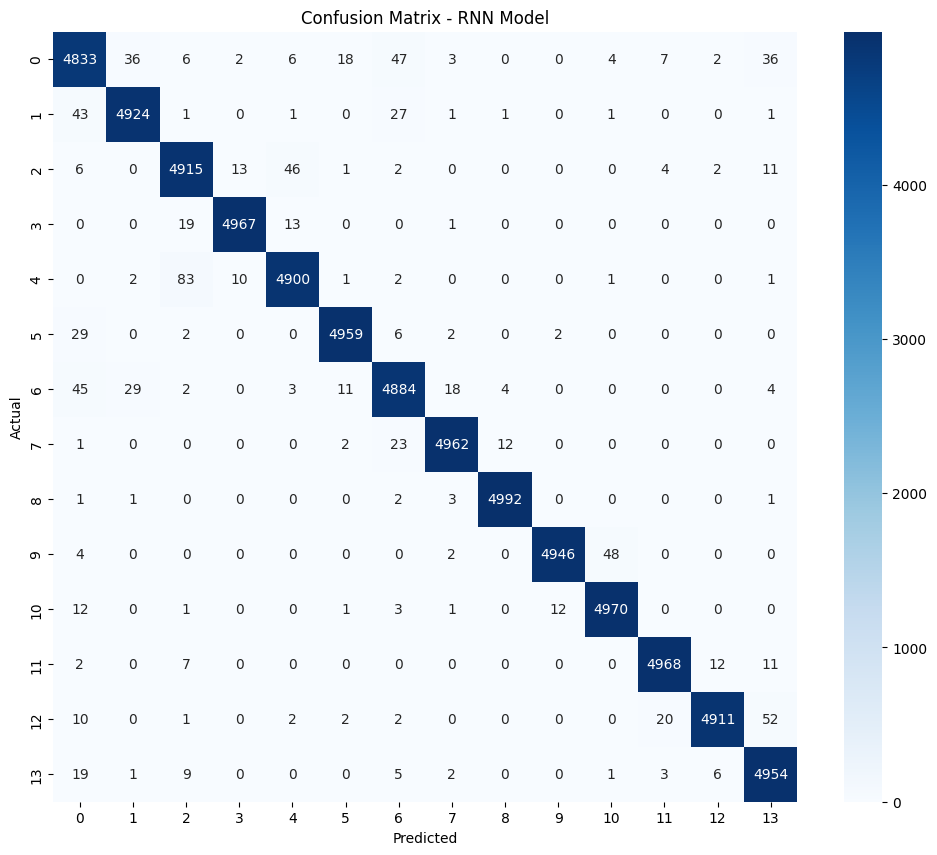


=== Sınıf Bazlı Doğruluk ===
Class 0: 0.9666
Class 1: 0.9848
Class 2: 0.9830
Class 3: 0.9934
Class 4: 0.9800
Class 5: 0.9918
Class 6: 0.9768
Class 7: 0.9924
Class 8: 0.9984
Class 9: 0.9892
Class 10: 0.9940
Class 11: 0.9936
Class 12: 0.9822
Class 13: 0.9908


In [10]:
# Test seti üzerinde değerlendirme
print("=== Test Seti Değerlendirmesi ===")

test_loss, test_accuracy = final_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Tahminler
y_pred_proba = final_model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# Classification report
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - RNN Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Sınıf bazlı accuracy
class_accuracies = cm.diagonal() / cm.sum(axis=1)
print("\n=== Sınıf Bazlı Doğruluk ===")
for i, acc in enumerate(class_accuracies):
    print(f"Class {i}: {acc:.4f}")

## 11. Training History Görselleştirme

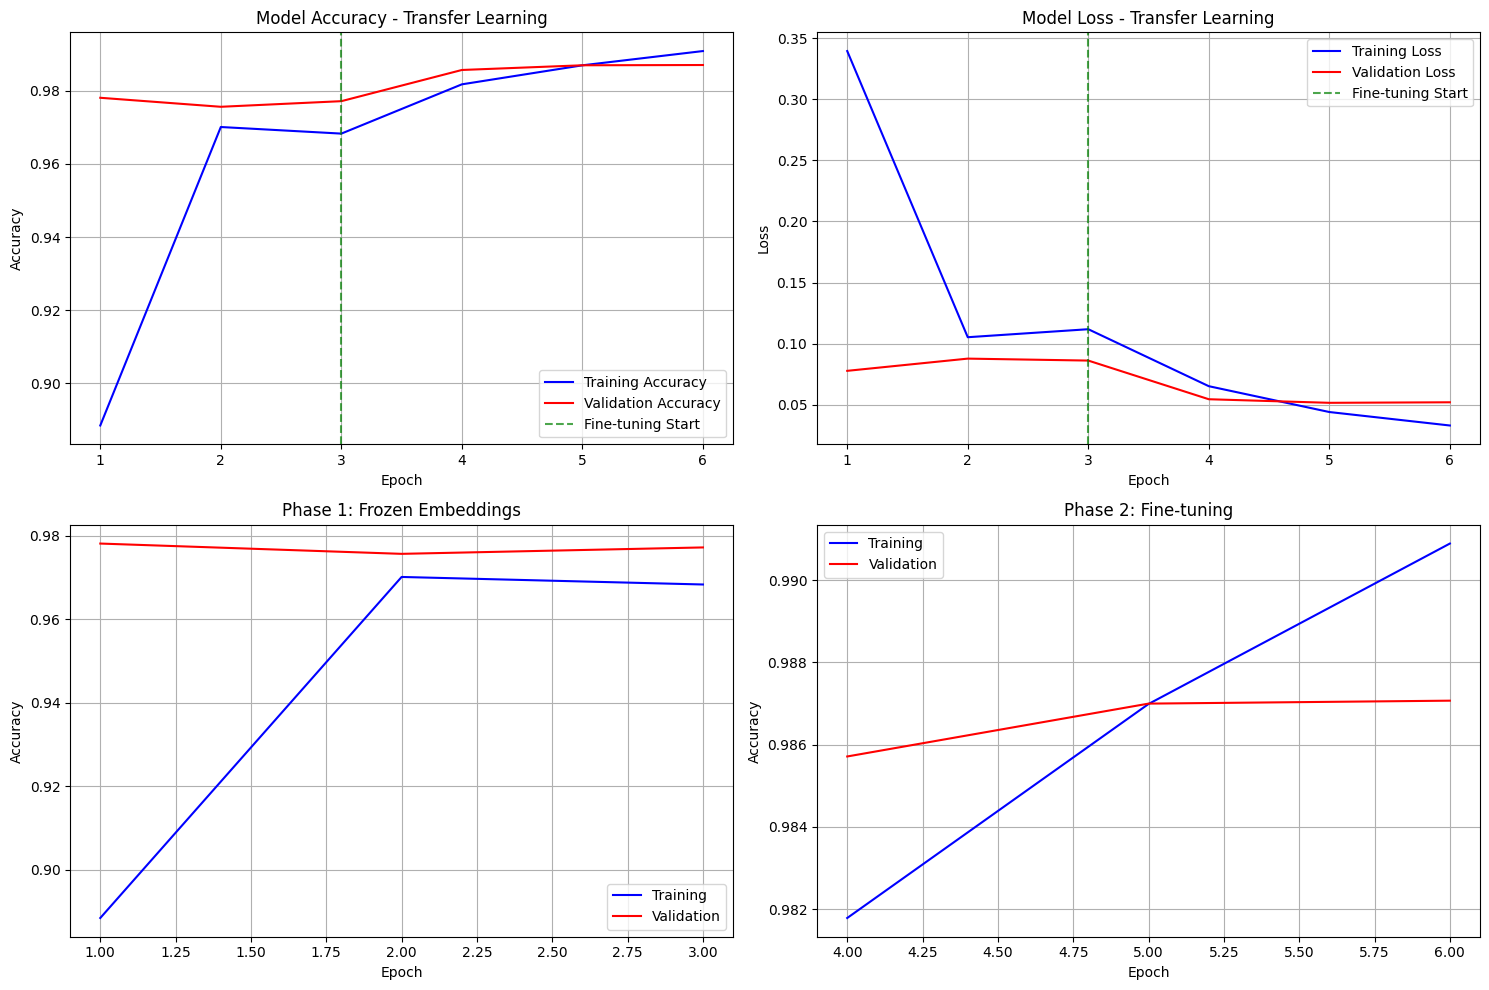

In [11]:
# Training history görselleştirme
def plot_training_history(history1, history2, title_suffix=""):
    """Training history'yi görselleştir"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Combine histories
    combined_history = {
        'accuracy': history1.history['accuracy'] + history2.history['accuracy'],
        'val_accuracy': history1.history['val_accuracy'] + history2.history['val_accuracy'],
        'loss': history1.history['loss'] + history2.history['loss'],
        'val_loss': history1.history['val_loss'] + history2.history['val_loss']
    }
    
    epochs = range(1, len(combined_history['accuracy']) + 1)
    phase1_end = len(history1.history['accuracy'])
    
    # Accuracy
    axes[0, 0].plot(epochs, combined_history['accuracy'], 'b-', label='Training Accuracy')
    axes[0, 0].plot(epochs, combined_history['val_accuracy'], 'r-', label='Validation Accuracy')
    axes[0, 0].axvline(x=phase1_end, color='g', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[0, 0].set_title('Model Accuracy' + title_suffix)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Loss
    axes[0, 1].plot(epochs, combined_history['loss'], 'b-', label='Training Loss')
    axes[0, 1].plot(epochs, combined_history['val_loss'], 'r-', label='Validation Loss')
    axes[0, 1].axvline(x=phase1_end, color='g', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[0, 1].set_title('Model Loss' + title_suffix)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Phase 1 only
    axes[1, 0].plot(range(1, phase1_end + 1), history1.history['accuracy'], 'b-', label='Training')
    axes[1, 0].plot(range(1, phase1_end + 1), history1.history['val_accuracy'], 'r-', label='Validation')
    axes[1, 0].set_title('Phase 1: Frozen Embeddings')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # Phase 2 only
    phase2_epochs = range(phase1_end + 1, len(combined_history['accuracy']) + 1)
    axes[1, 1].plot(phase2_epochs, history2.history['accuracy'], 'b-', label='Training')
    axes[1, 1].plot(phase2_epochs, history2.history['val_accuracy'], 'r-', label='Validation')
    axes[1, 1].set_title('Phase 2: Fine-tuning')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history_phase1, history_phase2, " - Transfer Learning")

## 12. Model Kaydetme ve Sonuçları Kaydetme

In [12]:
# Models2 klasörünü oluştur
if not os.path.exists('models2'):
    os.makedirs('models2')

# Model ve bileşenleri kaydet
final_model.save('models2/rnn_model_final.h5')

# Tokenizer kaydet
with open('models2/tokenizer_rnn.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Final embedding matrix kaydet
np.save('models2/embedding_matrix_rnn.npy', final_embedding_matrix)

model_config = {
    'best_params': best_params,
    'embedding_dim': final_embedding_dim,
    'max_sequence_length': MAX_SEQUENCE_LENGTH,
    'vocab_size': len(tokenizer.word_index) + 1,
    'num_classes': num_classes,
    'test_accuracy': test_accuracy,
    'test_loss': test_loss
}

with open('models2/rnn_model_config.pkl', 'wb') as f:
    pickle.dump(model_config, f)

# Sonuçları kaydet
results_summary = {
    'model_type': 'RNN_Transfer_Learning',
    'embedding_type': f'GloVe_{final_embedding_dim}D',
    'best_hyperparameters': best_params,
    'test_accuracy': test_accuracy,
    'test_loss': test_loss,
    'training_strategy': 'freeze_then_finetune',
    'max_sequence_length': MAX_SEQUENCE_LENGTH,
    'vocab_size': len(tokenizer.word_index),
    'class_accuracies': class_accuracies.tolist(),
    'speed_improvement': "No PCA applied"
}

with open('models2/rnn_results_summary.pkl', 'wb') as f:
    pickle.dump(results_summary, f)

print("=== Model ve Sonuçlar Kaydedildi ===")
print(f"Final test accuracy: {test_accuracy:.4f}")
print(f"Embedding boyutu: {EMBEDDING_DIM}D")
print(f"\\nKaydedilen dosyalar:")
print(f"- Model: models2/rnn_model_final.h5")
print(f"- Config: models2/rnn_model_config.pkl")
print(f"- Results: models2/rnn_results_summary.pkl")
print(f"- Tokenizer: models2/tokenizer_rnn.pkl")
print(f"- Embedding Matrix: models2/embedding_matrix_rnn.npy")

=== Model ve Sonuçlar Kaydedildi ===
Final test accuracy: 0.9869
Embedding boyutu: 100D
\nKaydedilen dosyalar:
- Model: models2/rnn_model_final.h5
- Config: models2/rnn_model_config.pkl
- Results: models2/rnn_results_summary.pkl
- Tokenizer: models2/tokenizer_rnn.pkl
- Embedding Matrix: models2/embedding_matrix_rnn.npy


## Sonuç ve Değerlendirme

Bu notebook'ta AG NEWS veri seti üzerinde RNN/LSTM tabanlı bir derin öğrenme modeli geliştirdik:

### Önemli Özellikler:
1. **GloVe Embeddings**: Önceden eğitilmiş 100D GloVe vektörleri
2. **Transfer Learning**: Freeze → Fine-tuning stratejisi
3. **Hiperparametre Optimizasyonu**: Random Search ile optimal parametreler
4. **Model Çeşitliliği**: LSTM, GRU, BiLSTM seçenekleri

### Teknik Detaylar:
- **Optimal Boyut Seçimi**: Random search ile en iyi embedding boyutu otomatik belirlenir

### Sonraki Adımlar:
- Klasik ML modelleriyle (TF-IDF + SVM/Naive Bayes) performans karşılaştırması